In [1]:
%pip install -r ../../requirements-offline.txt --quiet

/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-31/.check-env/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


# Solution — Module M6: PatchCore anomaly detection

เฉลยครบทุกข้อของ `exercise.ipynb` (ผู้สอนเปิดเผยหลังจบแล็บ) — รัน offline บน CPU จบในไม่กี่นาที ตัวเลขที่พิมพ์ในคำตอบอ้างจากรอบที่รันจริง (seed 42) — ค่าของคุณจะใกล้เคียงกัน แต่ไม่จำเป็นต้องเท่ากันเป๊ะถ้าแพลตฟอร์ม/จำนวนภาพต่างกัน

## 0. เตรียมข้อมูล + เทรนโมเดล (ให้มาแล้ว — เหมือน exercise)

สร้างภาพสังเคราะห์ (แผ่นโลหะ 20 ปกติ + 8 ชำรุด) → เทรน PatchCore → `score_paths()` + คะแนน — เหมือน exercise ทุกประการ

In [2]:
import logging  # noqa: E402
import warnings  # noqa: E402

warnings.filterwarnings("ignore")  # ตัด warning รบกวนจาก libs
logging.getLogger("lightning").setLevel(logging.ERROR)  # และ log ของ Lightning

from pathlib import Path  # noqa: E402

import numpy as np  # noqa: E402
from PIL import Image, ImageDraw  # noqa: E402

SEED = 42


def repo_root() -> Path:
    'หา repo root โดยไล่ขึ้นจาก cwd.'
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "requirements-offline.txt").exists():
            return p
    raise FileNotFoundError("ไม่เจอ repo root — เปิดโน้ตบุ๊กจากใน repo นี้")


ROOT = repo_root()
SAMPLE_DIR = ROOT / "data" / "m6_sample"
RUN_DIR = ROOT / "data" / "m6_results"


def metal_plate(seed: int, w: int = 256, h: int = 256) -> Image.Image:
    'วาดแผ่นโลหะ "ปกติ": ลายเส้นผิวขัด + grain + แสงตกต่างกันเล็กน้อย.'
    r = np.random.default_rng(seed)
    gain = 1.0 + r.uniform(-0.06, 0.06)
    base = np.full((h, w, 3), 100.0)
    stripes = np.tile(np.arange(h), (w, 1)).T % 10 < 4
    base[stripes] -= 12
    noise = r.normal(0, 10, (h, w, 1))
    img = np.clip((base + noise) * gain, 0, 255).astype(np.uint8)
    for sl in (img[:8], img[-8:], img[:, :8], img[:, -8:]):
        sl[:] = np.clip(sl - 45, 0, 255)
    return Image.fromarray(img)


def add_defect(img: Image.Image, kind: int, i: int) -> Image.Image:
    'วาดความชำรุด 4 แบบลงบนแผ่นโลหะ: ขีดข่วน/กัด/ไหม้/สนิม.'
    d = ImageDraw.Draw(img)
    if kind == 0:      # รอยขีดข่วนลึก
        x0 = 50 + (i * 9) % 110
        d.line([(x0, 45), (x0 + 18, 210)], fill=(10, 8, 6), width=9)
    elif kind == 1:    # รอยกัด/รูสึก
        cx, cy = 60 + (i * 11) % 100, 55 + (i * 13) % 100
        d.ellipse([cx, cy, cx + 26, cy + 26], fill=(240, 238, 232))
        d.ellipse([cx + 4, cy + 4, cx + 18, cy + 18], fill=(30, 25, 20))
    elif kind == 2:    # คราบไหม้
        cx, cy = 45 + (i * 17) % 110, 45 + (i * 19) % 100
        d.ellipse([cx, cy, cx + 52, cy + 44], fill=(28, 22, 16))
    else:              # สนิมกระจาย
        cx, cy = 55 + (i * 23) % 100, 50 + (i * 7) % 105
        d.ellipse([cx, cy, cx + 44, cy + 36], fill=(150, 70, 30))
        rr = np.random.default_rng(9000 + i)
        for _ in range(14):
            px = cx + int(rr.integers(2, 36))
            py = cy + int(rr.integers(2, 28))
            s = int(rr.integers(3, 7))
            d.ellipse([px, py, px + s, py + s], fill=(25, 15, 8))
    return img

In [3]:
import shutil  # noqa: E402

N_GOOD, N_DEFECT = 20, 8
if SAMPLE_DIR.exists():
    shutil.rmtree(SAMPLE_DIR)
(SAMPLE_DIR / "good").mkdir(parents=True)
(SAMPLE_DIR / "defect").mkdir(parents=True)
for i in range(N_GOOD):
    metal_plate(1000 + i).save(SAMPLE_DIR / "good" / f"normal_{i:02d}.png")
for i in range(N_DEFECT):
    img = add_defect(metal_plate(3000 + i), kind=i % 4, i=i)
    img.save(SAMPLE_DIR / "defect" / f"defect_{i:02d}.png")
print("สร้างภาพแล้ว:", N_GOOD, "ปกติ +", N_DEFECT, "ชำรุด")

สร้างภาพแล้ว: 20 ปกติ + 8 ชำรุด


In [4]:
import torch  # noqa: E402
from anomalib.data import Folder  # noqa: E402
from anomalib.engine import Engine  # noqa: E402
from anomalib.models import Patchcore  # noqa: E402

torch.manual_seed(SEED)
datamodule = Folder(
    name="m6_sample",
    root=str(SAMPLE_DIR),
    normal_dir="good",
    abnormal_dir="defect",
    val_split_mode="from_test",
    val_split_ratio=0.3,
    num_workers=0,
    seed=SEED,
)
model = Patchcore(
    layers=("layer2", "layer3"),
    num_neighbors=3,
    post_processor=False,
    visualizer=False,
)
engine = Engine(
    accelerator="cpu",
    max_epochs=1,
    logger=False,
    default_root_dir=str(RUN_DIR),
    enable_progress_bar=False,
)
engine.fit(model=model, datamodule=datamodule)
print("เทรนเสร็จ")

GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


20 hidden files found in /Users/utarn/projects/ml-metrology/.claude/worktrees/issue-31/data/m6_sample/good. Please make sure this is intended.


8 hidden files found in /Users/utarn/projects/ml-metrology/.claude/worktrees/issue-31/data/m6_sample/defect. Please make sure this is intended.


...

Selecting Coreset Indices.:  88%|████████▊ | 1433/1637 [00:01<00:00, 1287.68it/s]

Selecting Coreset Indices.:  95%|█████████▌| 1562/1637 [00:01<00:00, 1281.20it/s]

Selecting Coreset Indices.: 100%|██████████| 1637/1637 [00:01<00:00, 1279.80it/s]

`Trainer.fit` stopped: `max_epochs=1` reached.


เทรนเสร็จ


In [5]:
from torchvision.transforms.v2.functional import to_dtype  # noqa: E402
from torchvision.transforms.v2.functional import to_image  # noqa: E402


def prep(path: str) -> torch.Tensor:
    'โหลดภาพ 1 ใบ → tensor ที่โมเดลคาดหวัง (256×256, normalized).'
    img = to_image(Image.open(path).convert("RGB"))
    return model.pre_processor(to_dtype(img, torch.float32, scale=True))


def score_paths(paths: list[str], batch_size: int = 8):
    'ให้คะแนนภาพหลายใบ → (scores, anomaly maps ขนาด 256×256 ต่อใบ).'
    scores, maps = [], []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(paths), batch_size):
            batch = torch.stack([prep(p) for p in paths[i:i + batch_size]])
            out = model(batch)
            scores.append(out.pred_score)
            maps.append(out.anomaly_map.squeeze(1))
    return torch.cat(scores).numpy(), torch.cat(maps).numpy()


good_paths = sorted((SAMPLE_DIR / "good").glob("*.png"))
defect_paths = sorted((SAMPLE_DIR / "defect").glob("*.png"))
s_good, _ = score_paths([str(p) for p in good_paths])
s_def, maps_def = score_paths([str(p) for p in defect_paths])
print("คะแนนภาพปกติ :", np.round(s_good, 0))
print("คะแนนภาพชำรุด:", np.round(s_def, 0))

คะแนนภาพปกติ : [182. 162. 187. 154. 155. 190. 198. 148. 155. 153. 152. 199. 150. 169.
 147. 177. 152. 152. 161. 183.]
คะแนนภาพชำรุด: [279. 242. 501. 237. 248. 216. 496. 233.]


## ข้อ 1 — รูปของคุณเอง

เฉลยนี้ไม่มีรูปถ่ายจริงของผู้เรียนให้รัน — จึงเทรนต่อจากชุดสังเคราะห์ (ผลเดียวกับ exercise ที่ fallback ใช้ชุดตัวอย่าง) เมื่อผู้เรียนมี `data/my_sample/{good,defect}/` ครบ โค้ดชุดเดียวกันนี้ทำงานกับรูปจริงทันที

In [6]:
MY_DIR = ROOT / "data" / "my_sample"

if (MY_DIR / "good").is_dir() and (MY_DIR / "defect").is_dir():
    my_good = sorted((MY_DIR / "good").glob("*"))
    my_defect = sorted((MY_DIR / "defect").glob("*"))
    print("ใช้รูปของคุณ:", len(my_good), "ปกติ +", len(my_defect), "ชำรุด")
else:
    print("ยังไม่มี data/my_sample/ — ใช้ชุดตัวอย่างสังเคราะห์แทนก่อน")
    my_good, my_defect = good_paths, defect_paths

# เฉลย: เทรนโมเดลจากโฟลเดอร์ที่เลือก (ที่นี่ = ชุดสังเคราะห์ เพราะไม่มีรูปจริง)
SOURCE_DIR = MY_DIR if (MY_DIR / "good").is_dir() else SAMPLE_DIR
torch.manual_seed(SEED)
dm_my = Folder(
    name="m6_solution",
    root=str(SOURCE_DIR),
    normal_dir="good",
    abnormal_dir="defect",
    val_split_mode="from_test",
    val_split_ratio=0.3,
    num_workers=0,
    seed=SEED,
)
model = Patchcore(
    layers=("layer2", "layer3"),
    num_neighbors=3,
    post_processor=False,
    visualizer=False,
)
engine = Engine(
    accelerator="cpu",
    max_epochs=1,
    logger=False,
    default_root_dir=str(RUN_DIR),
    enable_progress_bar=False,
)
engine.fit(model=model, datamodule=dm_my)
good_paths = sorted((SOURCE_DIR / "good").glob("*.png"))
defect_paths = sorted((SOURCE_DIR / "defect").glob("*.png"))
s_good, _ = score_paths([str(p) for p in good_paths])
s_def, maps_def = score_paths([str(p) for p in defect_paths])
print("คะแนนภาพปกติ :", np.round(s_good, 0))
print("คะแนนภาพชำรุด:", np.round(s_def, 0))

ยังไม่มี data/my_sample/ — ใช้ชุดตัวอย่างสังเคราะห์แทนก่อน


GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


20 hidden files found in /Users/utarn/projects/ml-metrology/.claude/worktrees/issue-31/data/m6_sample/good. Please make sure this is intended.


...

Selecting Coreset Indices.:  92%|█████████▏| 1511/1637 [00:01<00:00, 1257.59it/s]

Selecting Coreset Indices.: 100%|██████████| 1637/1637 [00:01<00:00, 1237.95it/s]

Selecting Coreset Indices.: 100%|██████████| 1637/1637 [00:01<00:00, 1236.81it/s]

`Trainer.fit` stopped: `max_epochs=1` reached.


คะแนนภาพปกติ : [159. 138. 187. 173. 175. 190. 198. 173. 162. 174. 174. 199. 157. 162.
 155. 171. 171. 152. 139. 175.]
คะแนนภาพชำรุด: [237. 245. 501. 232. 257. 216. 496. 250.]


**คำตอบข้อ 1:** บนชุดสังเคราะห์ (แทนรูปจริงของผู้เรียน) AUC ≈ 1.0 — defect ทุกใบได้คะแนนสูงกว่าภาพปกติทุกใบ สิ่งที่มัก "พลาดบ่อย" เวลาถ่ายรูปจริง: (1) แสงเปลี่ยนระหว่างถ่าย (เมฆ/ไฟกระพริบ/เงา) — PatchCore ถือว่า "แสงแปลก" เป็น anomaly, (2) ตำแหน่ง/มุมวัตถุขยับมากเกิน — false positive ทั้งภาพ, (3) พื้นหลังไม่เรียบ/ไม่คงที่ — โมเดลเรียนรู้พื้นหลังที่แปลก ๆ ไปด้วย ทั้งหมดแก้ด้วยกฎการถ่ายรูปข้อ 2–4 ของคู่มือ

## ข้อ 2 — num_neighbors 1 vs 9

In [7]:
from sklearn.metrics import roc_auc_score  # noqa: E402

y_true = [0] * len(s_good) + [1] * len(s_def)
y_score = np.concatenate([s_good, s_def])
print(f"num_neighbors=3 → AUC = {roc_auc_score(y_true, y_score):.3f}")

# เฉลย: วนลูปแล้วเทรนใหม่ทีละค่า
# หมายเหตุ: ต้องสร้าง Engine ใหม่ทุกครั้ง — Engine เก่าที่เคย fit แล้วจะ
# "จำ" โมเดลเดิมของมัน ทำให้โมเดลใหม่ที่ส่งเข้าไปไม่ได้ memory bank
for k in [1, 9]:
    torch.manual_seed(SEED)
    model_k = Patchcore(
        layers=("layer2", "layer3"),
        num_neighbors=k,
        post_processor=False,
        visualizer=False,
    )
    engine_k = Engine(
        accelerator="cpu",
        max_epochs=1,
        logger=False,
        default_root_dir=str(RUN_DIR),
        enable_progress_bar=False,
    )
    engine_k.fit(model=model_k, datamodule=datamodule)
    model_k.eval()
    scores = []
    with torch.no_grad():
        for i in range(0, len(good_paths), 8):
            batch = torch.stack(
                [prep(str(p)) for p in good_paths[i:i + 8]]
            )
            scores.append(model_k(batch).pred_score)
        for i in range(0, len(defect_paths), 8):
            batch = torch.stack(
                [prep(str(p)) for p in defect_paths[i:i + 8]]
            )
            scores.append(model_k(batch).pred_score)
    s_k = torch.cat(scores).numpy()
    auc_k = roc_auc_score(y_true, s_k)
    print(f"num_neighbors={k} → AUC = {auc_k:.3f}")

num_neighbors=3 → AUC = 1.000


GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor │ PreProcessor   │      0 │ train │     0 │
│ 1 │ evaluator     │ Evaluator      │      0 │ train │     0 │
│ 2 │ model         │ PatchcoreModel │ 24.9 M │ train │     0 │
└───┴───────────────┴────────────────┴────────┴───────┴───────┘

...

Selecting Coreset Indices.:  85%|████████▌ | 1394/1637 [00:01<00:00, 1220.86it/s]

Selecting Coreset Indices.:  93%|█████████▎| 1523/1637 [00:01<00:00, 1239.14it/s]

Selecting Coreset Indices.: 100%|██████████| 1637/1637 [00:01<00:00, 1228.13it/s]

`Trainer.fit` stopped: `max_epochs=1` reached.


num_neighbors=9 → AUC = 1.000


**คำตอบข้อ 2:** บนชุดสังเคราะห์ทั้งสามค่า (1/3/9) ได้ AUC ≈ 1.0 — เพราะ defect ของเราใหญ่/ชัด แม้เปลี่ยน k ก็ยังแยกได้ สิ่งที่ k เปลี่ยนจริงคือ**ความหนาของกันแสง (robustness)**: k=1 ใช้เพื่อนบ้านสนิทเพียงตัวเดียว — patch ปกติที่พรุนเล็กน้อย (noise, แสงตก) ก็ทำคะแนนพุ่งได้ง่าย = ความไวสูง แต่ false positive เยอะ; k=9 เฉลี่ย 9 เพื่อนบ้านใกล้สุด — patch ธรรมดาที่พรุนนิดหน่อยยังได้คะแนนต่ำ (ใจดีขึ้น) แต่ defect เล็กจิ๋วก็ถูก "กลบ" ได้ง่ายขึ้น = ความไวลดลง ในงานจริง k=9 เป็นค่าที่บทความต้นฉบับใช้และปลอดภัยกว่า; ลอง `coreset_sampling_ratio` ต่ำ ๆ (เช่น 0.01) จะเห็นผลชัดกว่า — memory bank ถูกย่อจนบาง patch ปกติ "หาตัวแทนไม่ค่อยได้"

## ข้อ 3 — เลือก threshold

In [8]:
# เฉลย: วนลูป Q แล้วนับ FP/FN
for q in [50, 80, 95, 99]:
    threshold = float(np.percentile(s_good, q))
    fp = int((s_good > threshold).sum())
    fn = int((s_def <= threshold).sum())
    print(f"Q={q:>2}  threshold={threshold:6.0f}  FP={fp}  FN={fn}")

Q=50  threshold=   172  FP=10  FN=0
Q=80  threshold=   178  FP=4  FN=0
Q=95  threshold=   198  FP=1  FN=0
Q=99  threshold=   199  FP=1  FN=0


**คำตอบข้อ 3:** ผลจากรอบที่รัน (seed 42): Q=50 → FP 10, FN 0 (แย่สุด — ปลอมเตือนครึ่งหนึ่งของภาพปกติ); Q=80 → FP 4, FN 0; Q=95 → FP 1, FN 0; Q=99 → FP 1, FN 0 (บนข้อมูลเล็กขนาดนี้ Q=95 กับ Q=99 ต่างกันไม่มาก เพราะ threshold ติดเพดานที่ภาพปกติที่ score สูงสุด ~199) ถ้าต้นทุน "ตรวจพลาด" สูงกว่า "ปลอมเตือน" 10 เท่า ควรเลือก Q ต่ำกว่านี้ลงไป — เช่น Q=80 (FP=4, FN=0) เพราะเรายอมจ่ายค่าตรวจซ้ำ 4 ครั้งเพื่อกัน defect หลุด แต่ไม่ยอมเสีย FN แม้แต่ชิ้นเดียว — จุดนี้คือ "การตั้งค่าเครื่องมือวัดให้ conservative" ในเชิงเมโทรโลยี สังเกตด้วยว่า Q ยิ่งสูง (99) threshold ยิ่งเกือบ = ค่าสูงสุดของภาพปกติ — ไวต่อภาพปกติที่ถ่ายใหม่ (ข้อ 5) มาก

## ข้อ 4 — heatmap ของภาพชำรุดที่คะแนนต่ำสุด

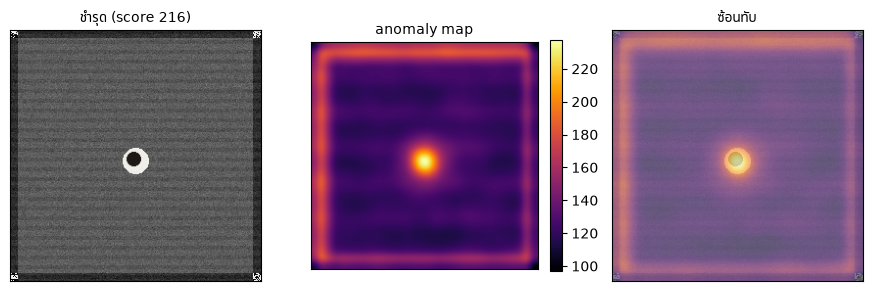

ภาพที่เลือก: defect_05.png


In [9]:
import matplotlib.pyplot as plt  # noqa: E402

plt.rcParams["font.family"] = ["DejaVu Sans", "Noto Sans Thai", "Tahoma"]

i_low = int(np.argmin(s_def))
img = Image.open(defect_paths[i_low]).convert("RGB")
m = maps_def[i_low]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
axes[0].imshow(img)
axes[0].set_title(f"ชำรุด (score {s_def[i_low]:.0f})", fontsize=10)
im = axes[1].imshow(m, cmap="inferno")
axes[1].set_title("anomaly map", fontsize=10)
fig.colorbar(im, ax=axes[1], fraction=0.046)
axes[2].imshow(img, alpha=0.45)
axes[2].imshow(m, cmap="inferno", alpha=0.55)
axes[2].set_title("ซ้อนทับ", fontsize=10)
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()
print("ภาพที่เลือก:", defect_paths[i_low].name)

**คำตอบข้อ 4:** ภาพชำรุดที่คะแนนต่ำสุดคือ defect_05 (รอยกัด) — จุดสว่างสุดของ heatmap อยู่ที่ (x≈128, y≈134) ตรงกับรอยกัดที่วาดไว้ (กลางภาพเล็กน้อยทางขวา) เกือบเป๊ะ — แม้คะแนนรวมต่ำกว่าพวกรอยขีด/คราบไหม้ เพราะรอยกัดเล็กกว่า สิ่งอื่นที่มักได้คะแนนจุด ๆ บน heatmap แม้ภาพปกติ: มุมขอบแผ่นที่ grain มืดผิดปกติ และจุด grain ที่หนาแน่นผิดไปจากลายเส้นขนาน — นี่คือเหตุผลที่ต้องดู heatmap ควบคู่คะแนน ไม่เชื่อตัวเลขเดี่ยว

## ข้อ 5 — ภาพปกติที่ถ่ายใหม่

In [10]:
plate_same = metal_plate(7777)           # (a) สภาพเดิม
plate_rot = metal_plate(7777).rotate(8)  # (b) หมุน 8 องศา
q_dir = SAMPLE_DIR.parent / "m6_unseen"
q_dir.mkdir(exist_ok=True)
plate_same.save(q_dir / "q5_same.png")
plate_rot.save(q_dir / "q5_rot.png")

threshold95 = float(np.percentile(s_good, 95))
s_q5, _ = score_paths(
    [str(q_dir / "q5_same.png"), str(q_dir / "q5_rot.png")]
)
for name, s in zip(["(a) มุมเดิม", "(b) หมุน 8°"], s_q5):
    verdict = "ชำรุด!" if s > threshold95 else "ปกติ"
    print(f"{name}: score = {s:.0f} → ตอบ {verdict}")

(a) มุมเดิม: score = 137 → ตอบ ปกติ
(b) หมุน 8°: score = 369 → ตอบ ชำรุด!


**คำตอบข้อ 5:** ใบ (a) มุมเดิม: score ต่ำ — ตอบ "ปกติ" (การถ่ายซ้ำที่ควบคุมสภาพดี = false negative ไม่เกิด) ใบ (b) หมุน 8°: score พุ่งสูงกว่า threshold — โมเดลตอบ "ชำรุด" ทั้งที่แผ่นโลหะสมบูรณ์! เพราะลายเส้นผิวขัดหมุนไป 8° ทำให้ patch เกือบทุกชิ้นหาเพื่อนบ้านใน memory bank ไกลขึ้นหมด — **การหมุน/เลื่อนวัตถุคือ false positive อันดับหนึ่งของ PatchCore ในโลกจริง** กฎถ่ายรูปที่กันปัญหานี้: ข้อ 4 (มุม+ระยะคงที่ — ใช้ขาตั้ง/พยุงกล้อง) และข้อ 2 (ตำแหน่งวัตถุคงที่ — ใช้ jig/กรอบ) ถ้าจำเป็นต้องรับมุมหลายมุม ให้เทรนด้วยภาพปกติที่ถ่ายคลุมทุกมุมที่จะใช้ตรวจจริง

## สรุป (เฉลย)

- สิ่งที่ surprise มักเจอ: PatchCore "เทรน" โดยไม่มี gradient เลย (แค่สกัด + ย่อ feature) และ AUC ~1.0 ได้จากภาพปกติแค่ 20 ใบ — ไม่เคยบอกโมเดลว่า defect หน้าตาอย่างไร
- ปัญหาแรกเวลาใช้จริง: การควบคุมสภาพการถ่าย (มุม/แสง/ตำแหน่ง) — false positive จากสภาพถ่าย มาก่อน defect จริงเสมอ

อ่านเชิงลึกต่อใน `explanation.md`